In [1]:
# asyncpg: 비동기, httpx: 외부 API(http)비동기 호출
%pip install asyncpg httpx python-dotenv
%pip install requests


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
# 테스트용 초기 state 만들기
from core.state import make_initial_state
from core.mocks import mock_user_input

initial_state = make_initial_state(mock_user_input)

In [4]:
# [노드] validate_input
# 사용자 입력 -> 좌표 변환, 식사 시간 계산 (전처리)
from nodes.validate_input import validate_input

validate_result = validate_input(initial_state)
# print("validate_input 결과:", validate_result)


In [5]:
# [노드] collect_candidate_pool
# kakao Local API로 raw 후보 풀 수집 + PostgreSQL
from nodes.collect_candidate_pool import collect_candidate_pool

candidates_result = await collect_candidate_pool(validate_result)
#print("candidates_result 결과:", candidates_result)


In [6]:
# [노드] first_filter_candidates
# 첫번쨰 필터 -> 50개 축소
from nodes.first_filter_candidates import first_filter_candidates

filter_result = first_filter_candidates(candidates_result, debug=True)

print(f"\n📌 warnings:")
for w in filter_result["warnings"]:
    print(f"   - {w}")


📦 시작
   ──────────────────────────────────────────────────
   ✂️  제거: 0개  |  남은: 275개
   📊 카테고리: :110  FD6:68  CE7:59  AD5:12  AT4:9  PK6:7
🔍 전체 장소 목록:
01. [CE7] 오프온 | 음식점 > 카페
02. [CE7] 카페해운대1994 | 음식점 > 카페
03. [CE7] 부산바다샌드 해운대본점 | 음식점 > 카페 > 테마카페 > 디저트카페
04. [CE7] 카페히토 | 음식점 > 카페
05. [CE7] 블랙업커피 해운대점 | 음식점 > 카페 > 커피전문점
06. [CE7] 듀플릿 | 음식점 > 카페 > 테마카페 > 디저트카페
07. [CE7] 금송덕미 해리단길점 | 음식점 > 카페 > 테마카페 > 디저트카페
08. [CE7] 브레이크아웃이스케이프 해운대본점 | 음식점 > 카페 > 테마카페
09. [CE7] 투썸플레이스 해운대센트럴푸르지오점 | 음식점 > 카페 > 커피전문점 > 투썸플레이스
10. [CE7] 코오리마찌 | 음식점 > 카페 > 테마카페 > 디저트카페
11. [CE7] 모루씨 해리단길점 | 음식점 > 카페 > 커피전문점
12. [CE7] 로우앤스윗 로스터리 | 음식점 > 카페
13. [CE7] 제스터 | 음식점 > 카페
14. [CE7] 하브커피 | 음식점 > 카페 > 커피전문점
15. [CE7] 워킹홀리데이 해운대 | 음식점 > 카페
16. [CE7] 홈즈앤루팡 해운대점 | 가정,생활 > 여가시설 > 보드카페 > 홈즈앤루팡
17. [CE7] 로우앤스윗 해운대카페 | 음식점 > 카페 > 커피전문점
18. [CE7] 해운대옛날팥빙수단팥죽 | 음식점 > 카페 > 테마카페 > 디저트카페
19. [CE7] 프라한 해운대점 | 음식점 > 카페 > 테마카페
20. [CE7] 스타벅스 하버타운점 | 음식점 > 카페 > 커피전문점 > 스타벅스
21. [CE7] 엡섬 | 음식점 > 카페
22. [CE7] 카페플럼피 | 음식점 > 카페 > 커피전문점

In [7]:
# [노드] second_filter_candidates
# 두번쨰 필터 -> 30개 축소
from nodes.second_filter_candidates import second_filter_candidates

test_state = {
    "filtered_candidates": filter_result["filtered_candidates"],
    "user_input": mock_user_input,
    "warnings": [],
}

second_filter_result = await second_filter_candidates(test_state)

print(f"⚠️ warnings: {second_filter_result['warnings']}")
print(f"✅ step: {second_filter_result['step']}")
print(f"📦 보강된 장소 수: {len(second_filter_result['filtered_candidates'])}")
print(f"📊 scored_candidates 수: {len(second_filter_result['scored_candidates'])}")
print(f"🏆 shortlist 수: {len(second_filter_result['shortlist'])}")

print("\n=== 전체 scored_candidates (50개) ===")

for i, s in enumerate(second_filter_result["scored_candidates"], 1):
    p = s["place"]

    print(f"""
{i}위. {p['name']}
  분위기: {p.get('atmosphere')}
  추천대상: {p.get('best_for')}
  활동: {p.get('place_tags')}
  재방문의사: {p.get('revisit_intent')}
  한줄요약: {p.get('summary')}
  mood_score: {s['mood_score']}
  activity_score: {s['activity_score']}
  party_fit_score: {s['party_fit_score']}
  total_score: {s['total_score']}
""")


print("\n=== shortlist (최종 30개) ===")

for i, s in enumerate(second_filter_result["shortlist"], 1):
    p = s["place"]

    print(f"""
{i}위. {p['name']}
  total_score: {s['total_score']}
  bucket: {p.get('bucket')}
""")

⏱  네이버 블로그: 11.5초 (50개)
⏱  LLM 보강: 17.1초 (50개)
⚠️ warnings: []
✅ step: enriched
📦 보강된 장소 수: 50
📊 scored_candidates 수: 50
🏆 shortlist 수: 30

=== 전체 scored_candidates (50개) ===

1위. 빨간떡볶이
  분위기: ['활기찬', '이색']
  추천대상: ['친구', '연인']
  활동: ['떡볶이', '분식', '부산']
  재방문의사: high
  한줄요약: 매운맛이 아닌 편안한 떡볶이.
  mood_score: 20
  activity_score: 0
  party_fit_score: 40
  total_score: 90


2위. 해운대초량밀면
  분위기: ['활기찬', '이색']
  추천대상: ['친구', '연인']
  활동: ['밀면', '한식', '부산']
  재방문의사: high
  한줄요약: 해운대의 인기 밀면 맛집.
  mood_score: 20
  activity_score: 0
  party_fit_score: 40
  total_score: 90


3위. 워킹홀리데이 해운대
  분위기: ['힐링', '로맨틱']
  추천대상: ['연인']
  활동: ['카페', '오션뷰', '해운대']
  재방문의사: high
  한줄요약: 해운대 바다뷰 카페에서 힐링.
  mood_score: 10
  activity_score: 10
  party_fit_score: 40
  total_score: 90


4위. 씨라이프 부산아쿠아리움
  분위기: ['힐링', '감성']
  추천대상: ['연인', '가족']
  활동: ['아쿠아리움', '바다', '관람']
  재방문의사: high
  한줄요약: 아름다운 수중 생물을 관람할 수 있는 아쿠아리움.
  mood_score: 10
  activity_score: 10
  party_fit_score: 40
  total_score: 90


5위. 해운대블루라인파크 미포정거장


In [12]:
# [노드] travel_matrix
# shortlist 30개 장소 간 이동시간 행렬 계산
from nodes.travel_matrix import travel_matrix

matrix_result = travel_matrix(second_filter_result)

# place_id → name 매핑
id_to_name = {item["place"]["id"]: item["place"]["name"] for item in second_filter_result["shortlist"]}

print(f"✅ place_index: {len(matrix_result['place_index'])}개")
print(f"✅ distance_matrix: {len(matrix_result['distance_matrix'])}x{len(matrix_result['distance_matrix'][0])}")
print(f"✅ time_matrix: {len(matrix_result['time_matrix'])}x{len(matrix_result['time_matrix'][0])}")

for i, from_id in enumerate(matrix_result['place_index']):
    print(f"\n📍 {id_to_name[from_id]} 에서:")
    for to_id, mins in zip(matrix_result['place_index'], matrix_result['time_matrix'][i]):
        if from_id == to_id:
            continue
        print(f"  → {id_to_name[to_id]}: {mins}분")

✅ place_index: 30개
✅ distance_matrix: 30x30
✅ time_matrix: 30x30

📍 워킹홀리데이 해운대 에서:
  → 빨간떡볶이: 9.5분
  → 해운대초량밀면: 4.5분
  → 씨라이프 부산아쿠아리움: 1.2분
  → 해운대블루라인파크 미포정거장: 15.6분
  → 카페해운대1994: 6.9분
  → 카페히토: 9.6분
  → 블랙업커피 해운대점: 6.9분
  → 모루씨 해리단길점: 10.5분
  → 로우앤스윗 로스터리: 9.0분
  → 강릉송정해변막국수 부산분점: 15.5분
  → 오복돼지국밥: 5.0분
  → 해운대원조할매국밥: 5.7분
  → 가야밀면: 9.5분
  → 나가하마만게츠: 12.4분
  → 플레이포인트랩 해운대 블루오션스테이션점: 6.7분
  → 동백공원 해안산책로: 14.5분
  → 해운대해수욕장: 3.3분
  → 할매탕: 7.2분
  → 해운대 바다김밥: 5.0분
  → 왕미미오락실: 4.0분
  → 민트플레이 해운대2호점: 6.7분
  → 사격팡 해운대점: 1.7분
  → 봉봉스테이션 해운대점: 20.7분
  → 오션스타: 1.9분
  → 바다내음공원: 14.4분
  → 해변문화관: 2.2분
  → 부산바다축제: 3.2분
  → 바다위구름상점: 2.3분
  → 브레이크아웃이스케이프 해운대본점: 1.9분

📍 빨간떡볶이 에서:
  → 워킹홀리데이 해운대: 9.5분
  → 해운대초량밀면: 5.7분
  → 씨라이프 부산아쿠아리움: 10.3분
  → 해운대블루라인파크 미포정거장: 20.8분
  → 카페해운대1994: 4.7분
  → 카페히토: 6.5분
  → 블랙업커피 해운대점: 6.4분
  → 모루씨 해리단길점: 3.9분
  → 로우앤스윗 로스터리: 4.5분
  → 강릉송정해변막국수 부산분점: 17.4분
  → 오복돼지국밥: 5.0분
  → 해운대원조할매국밥: 3.9분
  → 가야밀면: 0.1분
  → 나가하마만게츠: 4.5분
  → 플레이포인트랩 해운대 블루오션스테이션점: 5.1분
  → 동백공원 해안

In [9]:
# LangGraph 그래프 빌드
from langgraph.graph import StateGraph, START, END
from core.state import TravelState

graph_builder = StateGraph(TravelState)

# 노드 등록
graph_builder.add_node("validate_input", validate_input)
graph_builder.add_node("collect_candidate_pool", collect_candidate_pool)
graph_builder.add_node("first_filter_candidates", first_filter_candidates)
graph_builder.add_node("second_filter_candidates", second_filter_candidates)
graph_builder.add_node("travel_matrix", travel_matrix)

# 엣지 (직선 연결)
graph_builder.add_edge(START, "validate_input")
graph_builder.add_edge("validate_input", "collect_candidate_pool")
graph_builder.add_edge("collect_candidate_pool", "first_filter_candidates")
graph_builder.add_edge("first_filter_candidates", "second_filter_candidates")
graph_builder.add_edge("second_filter_candidates", "travel_matrix")
graph_builder.add_edge("travel_matrix", END)

graph = graph_builder.compile()

In [10]:
# 그래프 실행
state_v1 = await graph.ainvoke(initial_state)

print(f"📍 위치: {state_v1['user_input']['location']}")
print(f"📌 좌표: ({state_v1['user_input']['center_lat']}, {state_v1['user_input']['center_lng']})")
print(f"🔍 Kakao raw 후보: {len(state_v1['candidates'])}개")
print(f"⚠️  warnings: {state_v1['warnings']}")
print(f"❌ errors: {state_v1['errors']}")
print(f"✅ step: {state_v1['step']}\n")

for p in filter_result["filtered_candidates"][:5]:
    print(
        f"  [{p.get('category_group_code', '기타')}] {p['name']} - "
        f"{p.get('road_address_name') or p.get('address_name', '')}"
    )

⏱  네이버 블로그: 10.7초 (50개)
⏱  LLM 보강: 15.7초 (50개)
📍 위치: 해운대역
📌 좌표: (35.1636479638612, 129.158897240251)
🔍 Kakao raw 후보: 275개
⚠️  warnings: []
❌ errors: []
✅ step: matrix_built

  [FD6] 강릉송정해변막국수 부산분점 - 부산 해운대구 좌동순환로446번길 15-6
  [FD6] 해운대 바다김밥 - 부산 해운대구 중동1로 33-1
  [FD6] 바다마루전복죽 - 부산 해운대구 달맞이길62번길 7
  [FD6] 온천떡집 - 부산 해운대구 구남로41번길 33
  [FD6] 빨간떡볶이 - 부산 해운대구 우동1로20번길 74


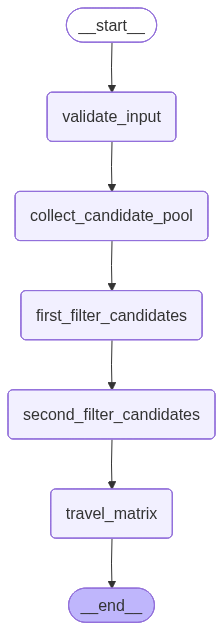

In [11]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))